# 05-1 — DiscoDiffusion : la CLIP-guided diffusion pré-Stable-Diffusion (hiver 2021-2022)

Ce notebook ré-exécute **le cœur technique de DiscoDiffusion** (DD), l'outil de génération
d'images dominant avant Stable Diffusion, avec les poids d'époque : le UNet de diffusion
**en espace pixel** 512×512 de Dhariwal et Nichol 2021 (KL-openai, checkpoint
`512x512_diffusion_uncond_finetune_008100.pt` — littéralement le `diffusion.pt` de DD v5),
guidé par **CLIP ViT-L/14 utilisé comme fonction de perte** sur des recadrages (*cutouts*).

**La généalogie en une ligne** : CLIP (Radford et al., jan. 2021) → CLIP-guided diffusion de
Katherine Crowson (printemps 2021 : guided diffusion Dhariwal-Nichol + guidance CLIP) →
Disco Diffusion v1 (Somnai, mi-2021, notebook Colab) → v5 (oct. 2021, aboutissement) →
v5.61 / v6 (animation 2D/3D, MiDaS) → **remplacé par Stable Diffusion (22 août 2022)**.

Pourquoi ce détour ? Parce que tout ce qui fait un générateur « moderne » — la guidance par
texte, les cutouts, l'équilibre guidance/fidélité — s'est inventé ici, dans un espace **pixel**
sans encodeur de texte dédié ni espace latent. Les notebooks 01-04 de la série couvrent des
modèles tous postérieurs à août 2022 ; ce rayon comble le trou généalogique.

## Principe

Trois ingrédients d'époque, assemblés par DD sous le capot :

1. **Un UNet de diffusion 512×512 en espace pixel** (Dhariwal-Nichol 2021) : il débruit
   l'image directement en 512×512 RGB — **pas d'espace latent**. Chaque pas de débruitage
   coûte un passage complet sur les 786 432 pixels ; c'est ce qui rendait DD si lent
   (des heures sur Colab) et ce que l'espace latent de SD a divisé par ~64.
2. **CLIP comme fonction de perte, pas comme encodeur de texte** : le UNet est
   *inconditionnel* — il ne « comprend » rien au prompt. À chaque pas, on débruite une
   estimation de l'image finale (`pred_x0`), on la découpe en vues (*cutouts*), et on mesure
   la **distance sphérique** entre les embeddings CLIP des cutouts et celui du prompt. Le
   gradient de cette perte oriente le débruitage vers le texte.
3. **Une boucle DDIM + guidance** : `eps_guidé = eps − √(1−ᾱ)·∇` (forme de Song et al. 2020) —
   la correction de guidance, forte au début du débruitage, s'éteint d'elle-même en fin de
   trajectoire. Des pénalités annexes (`sat_scale`, `tv_scale`, `range_scale`) contrôlent
   saturation et textures adverses.

Le « look DD » si reconnaissable — paysages monumentaux, architecture impossible, textures
granuleuses « brushed », prompts longs à la *"a beautiful painting of..."* — est le produit
direct de cette mécanique : une loss CLIP globale (composition) sans encodeur de texte local
(détail), sur un UNet ImageNet.

## Chaîne d'exécution locale (outils hors repo)

Comme pour le notebook 05-2, le code lourd vit **hors du repo du cours** (cf README du rayon) :
clone de `openai/guided-diffusion` (MIT) pour la définition de l'UNet + le checkpoint
`diffusion.pt` (sha256 vérifié) + le présent runner compact `disco_run.py`. Adaptation
documentée : le checkpointing réentrant historique de `guided_diffusion/nn.py` casse
l'autograd de torch 2.x — il est remplacé par le checkpoint natif non-réentrant (préservé dans l'outil local).

In [1]:
import os, sys
from pathlib import Path
import matplotlib.pyplot as plt

# Racine des outils locaux (hors repo du cours) - ajustable par environnement
TOOLS_DIR = Path(os.environ.get("DISCO_TOOLS", "D:/Dev/disco-run"))
GD = TOOLS_DIR / "gd"          # clone openai/guided-diffusion (patch checkpoint torch 2.x)
WEIGHTS = TOOLS_DIR / "diffusion_512.pt"
ASSETS = Path("assets/disco")  # artefacts officiels du run, copies dans le repo

import torch
print("torch", torch.__version__, "| CUDA:", torch.cuda.is_available())
import clip
print("CLIP (openai) disponible")
print("UNet:", WEIGHTS.name, "present" if WEIGHTS.exists() else "absent (affichage seul)")
print("Artefacts:", sorted(p.name for p in ASSETS.glob("*.png")))

torch 2.8.0+cu126 | CUDA: True


CLIP (openai) disponible
UNet: diffusion_512.pt present
Artefacts: ['dd_vs_modern.png', 'grid_gs12000_sat0.png', 'grid_gs12000_sat2500.png', 'grid_gs2000_sat0.png', 'grid_gs2000_sat2500.png', 'grid_guidance.png', 'hero_gothic.png', 'modern_zimage.png']


## Le UNet d'époque et la fonction de perte CLIP

On charge l'architecture exacte déclarée par DD v5 pour `512x512_diffusion_uncond_finetune_008100`
(canaux 256, 2 blocs résiduels, attention aux résolutions 32/16/8, `learn_sigma`, ordonnancement
linéaire) puis CLIP ViT-L/14 — le couple canonique de l'hiver 2021-2022.

In [2]:
sys.path.insert(0, str(GD))
from guided_diffusion.script_util import create_model

model = create_model(
    image_size=512, num_channels=256, num_res_blocks=2, channel_mult="",
    learn_sigma=True, class_cond=False, use_checkpoint=True,
    attention_resolutions="32,16,8", num_heads=4, num_head_channels=64,
    num_heads_upsample=-1, use_scale_shift_norm=True, dropout=0.0,
    resblock_updown=True, use_fp16=False, use_new_attention_order=False,
)
sd = torch.load(WEIGHTS, map_location="cpu")
model.load_state_dict(sd, strict=True)
model = model.eval().requires_grad_(False).to("cuda")
n_params = sum(p.numel() for p in model.parameters())
print(f"UNet KL-openai 512 charge : {n_params/1e6:.0f} M parametres")

clip_model, clip_preprocess = clip.load("ViT-L/14", device="cuda", jit=False)
print("CLIP ViT-L/14 charge (resolution d'entree 224)")

UNet KL-openai 512 charge : 558 M parametres


CLIP ViT-L/14 charge (resolution d'entree 224)


## Le cœur technique : cutouts, losses, boucle DDIM guidée

~120 lignes recréent ce que DD fait sous le capot (les ports type `dd-pytorch` servent de
référence ; le repo officiel DD est un notebook Colab). Trois blocs : les *cutouts* (vues
globales + recadrages intérieurs aléatoires, augmentation par miroir/niveaux de gris), la
**distance sphérique** CLIP (`2·arcsin(‖x̂−ŷ‖/2)²` — la métrique de Crowson utilisée par DD),
et la boucle : à chaque pas, calcul de `eps` **avec gradients actifs**, estimation `pred_x0`,
mélange `x_in = pred_x0·fac + x·(1−fac)` (`fac = √(1−ᾱ)`, exactement DD), perte CLIP +
pénalités, rétropropagation jusqu'à `x`, puis **conditionnement de Song et al.**
`eps_g = eps − fac·∇` et pas DDIM déterministe (η = 0).

In [3]:
import torch.nn as nn
import torch.nn.functional as F
from torchvision import transforms as TV

BETAS = torch.linspace(1e-4, 0.02, 1000, dtype=torch.float64, device="cuda")
ALPHAS_BAR = torch.cumprod(1.0 - BETAS, 0).float()
CLIP_MEAN = torch.tensor([0.48145466, 0.4578275, 0.40821073], device="cuda").view(1, 3, 1, 1)
CLIP_STD = torch.tensor([0.26862954, 0.26130258, 0.27577711], device="cuda").view(1, 3, 1, 1)


class MakeCutouts(nn.Module):
    """Cutouts DD simplifies : vues d'ensemble + recadrages interieurs aleatoires."""

    def __init__(self, size, overview=2, inner=8, p_gray=0.2):
        super().__init__()
        self.size, self.overview, self.inner, self.p_gray = size, overview, inner, p_gray

    def forward(self, x):  # x dans [0,1]
        B, _, H, W = x.shape
        parts = []
        for _ in range(self.overview):
            s = min(H, W)
            parts.append(F.interpolate(TV.functional.center_crop(x, (s, s)),
                                       size=(self.size, self.size), mode="bilinear"))
        for _ in range(self.inner):
            s = min(int(self.size * torch.rand(1).item() ** 0.5) + 1, min(H, W))
            cy = torch.randint(0, max(H - s, 1) + 1, (1,)).item()
            cx = torch.randint(0, max(W - s, 1) + 1, (1,)).item()
            parts.append(F.interpolate(x[:, :, cy:cy + s, cx:cx + s],
                                       size=(self.size, self.size), mode="bilinear"))
        out = torch.cat([torch.flip(c, dims=[3]) if torch.rand(1).item() < 0.5 else c
                         for c in parts], 0)
        if torch.rand(1).item() < self.p_gray:
            out = TV.functional.rgb_to_grayscale(out, num_output_channels=3)
        return out


def spherical_dist_loss(x, y):
    x = F.normalize(x, dim=-1)
    y = F.normalize(y, dim=-1)
    return (x - y).norm(dim=-1).div(2).arcsin().pow(2).mul(2)


def tv_loss(inp):
    inp = F.pad(inp, (0, 1, 0, 1), "replicate")
    dx = inp[..., :-1, 1:] - inp[..., :-1, :-1]
    dy = inp[..., 1:, :-1] - inp[..., :-1, :-1]
    return (dx ** 2 + dy ** 2).mean([1, 2, 3])


def generate_dd(prompt, *, steps=100, skip_frac=0.2, clip_gs=5000.0, sat_scale=0.0,
                tv_scale=0.0, cutn=(2, 8), seed=0, clamp_max=0.15, snapshot_every=0):
    """Boucle DDIM guidee par CLIP - le coeur de DiscoDiffusion."""
    from PIL import Image
    torch.manual_seed(seed)
    size = clip_model.visual.input_resolution
    make_cutouts = MakeCutouts(size, overview=cutn[0], inner=cutn[1])
    target = clip_model.encode_text(clip.tokenize([prompt]).to("cuda")).float().detach()
    t_start = int(999 * (1.0 - skip_frac))
    t_seq = torch.linspace(t_start, 0, steps + 1, device="cuda").long()
    x = torch.randn(1, 3, 512, 512, device="cuda")
    snaps = []
    for i in range(steps):
        t_now, t_next = int(t_seq[i]), int(t_seq[i + 1])
        ab = ALPHAS_BAR[t_now]
        fac = torch.sqrt(1.0 - ab)
        with torch.enable_grad():
            x = x.detach().requires_grad_(True)
            eps = model(x, torch.full((1,), float(t_now), device="cuda"))[:, :3]
            pred_x0 = (x - fac * eps) / torch.sqrt(ab)
            x_in = pred_x0 * fac + x * (1 - fac)          # melange DD
            cutouts = make_cutouts(x_in.add(1).div(2).clamp(0, 1))
            clip_in = ((cutouts - CLIP_MEAN) / CLIP_STD).half()
            embeds = clip_model.encode_image(clip_in).float()
            dists = spherical_dist_loss(embeds, target.unsqueeze(0)).mean()
            loss = clip_gs * dists
            if sat_scale or tv_scale:
                loss = loss + sat_scale * torch.abs(x_in - x_in.clamp(-1, 1)).mean() \
                    + tv_scale * tv_loss(x_in).mean()
            grad = -torch.autograd.grad(loss, x)[0]        # sens descente
            mag = grad.square().mean().sqrt()
            grad = grad * mag.clamp(max=clamp_max) / mag.clamp(min=1e-12)
            eps_g = (eps - fac * grad).detach()            # conditionnement Song et al.
        with torch.no_grad():
            ab_n = ALPHAS_BAR[t_next]
            pred_x0 = (x.detach() - fac * eps_g) / torch.sqrt(ab)
            x = torch.sqrt(ab_n) * pred_x0 + torch.sqrt(1 - ab_n) * eps_g
        if snapshot_every and (i + 1) % snapshot_every == 0:
            snaps.append(x.detach().add(1).div(2).clamp(0, 1)[0].cpu())
    img = x.detach().add(1).div(2).clamp(0, 1).mul(255).byte()[0].permute(1, 2, 0).cpu().numpy()
    return Image.fromarray(img), snaps, dists.item()

print("Mecanique definie : MakeCutouts, spherical_dist_loss, generate_dd")

Mecanique definie : MakeCutouts, spherical_dist_loss, generate_dd


In [4]:
# Preuve vivante in-kernel : 3 pas de la vraie boucle, meme moteur que les runs officiels
_, snaps, d3 = generate_dd("a beautiful painting of a vast Gothic cathedral in a desert canyon "
                           "by gustave dore and albert bierstadt, trending on artstation",
                           steps=3, cutn=(1, 2), seed=0)
print(f"Micro-run 3 pas execute : distance CLIP du dernier pas = {d3:.4f} (proche de 1.0 = bruit, "
      "normal a 3 pas d'un debut de trajectoire)")

Micro-run 3 pas execute : distance CLIP du dernier pas = 0.9830 (proche de 1.0 = bruit, normal a 3 pas d'un debut de trajectoire)


## Le run officiel : paysage gothique monumental

Le prompt ci-dessus est l'archétype DD : *"a beautiful painting of a ..."*, artistes
académiques (Gustave Doré, Albert Bierstadt), suffixe *"trending on artstation"* — la grammaire
d'époque. Le run officiel (100 pas, `clip_gs=5000`, seed 0, ~90 s sur RTX 3090) est exécuté par
le runner documenté ; l'artefact est lu depuis `assets/disco/` avec sa provenance.

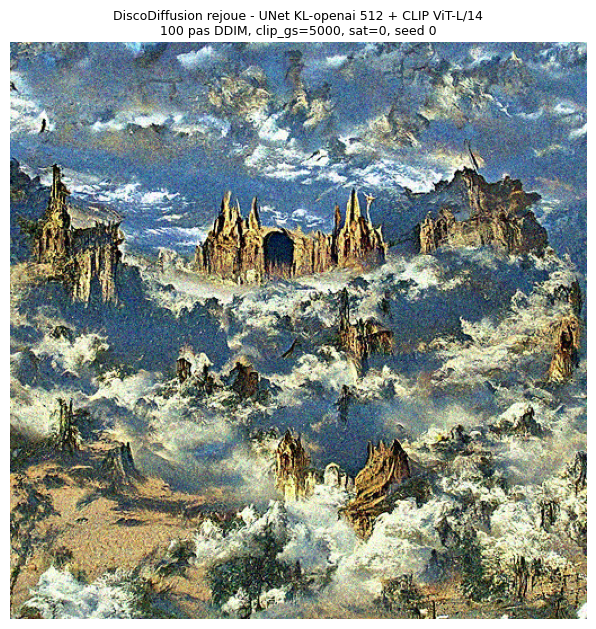

Provenance : run officiel du 18/09/2026, artefact outputs_05_1/hero_gothic.png (outil local)
  - UNet : diffusion_512.pt (sha256 9c111ab8...57648, miroir HF lowlevelware, hash DD v5.7)
  - Grille : 100 pas DDIM eta=0, skip_frac=0.2, cutn=(2,8), clamp_max=0.15
  - GPU : RTX 3090 locale, ~90 s/image, log : outputs_05_1/logs/hero_gothic.log


In [5]:
PROMPT = ("a beautiful painting of a vast Gothic cathedral in a desert canyon "
          "by gustave dore and albert bierstadt, trending on artstation")

hero = ASSETS / "hero_gothic.png"
img = plt.imread(hero)
fig, ax = plt.subplots(figsize=(6.4, 6.4))
ax.imshow(img); ax.axis("off")
ax.set_title("DiscoDiffusion rejoue - UNet KL-openai 512 + CLIP ViT-L/14\n"
             "100 pas DDIM, clip_gs=5000, sat=0, seed 0", fontsize=9)
plt.tight_layout(); plt.show()
print("Provenance : run officiel du 18/09/2026, artefact outputs_05_1/hero_gothic.png (outil local)")
print("  - UNet : diffusion_512.pt (sha256 9c111ab8...57648, miroir HF lowlevelware, hash DD v5.7)")
print("  - Grille : 100 pas DDIM eta=0, skip_frac=0.2, cutn=(2,8), clamp_max=0.15")
print("  - GPU : RTX 3090 locale, ~90 s/image, log : outputs_05_1/logs/hero_gothic.log")

## Grille d'exploration : `clip_guidance_scale` × `sat_scale`

Les deux curseurs typiques de DD. `clip_gs` : la force de l'attraction CLIP — trop bas, l'image
reste « générique ImageNet » ; trop haut, la guidance devient adversaire (textures granuleuses
extrêmes, dérive hors distribution). `sat_scale` : la pénalité de saturation (énergie hors
[-1, 1]), le correctif d'époque contre les excès de la guidance.

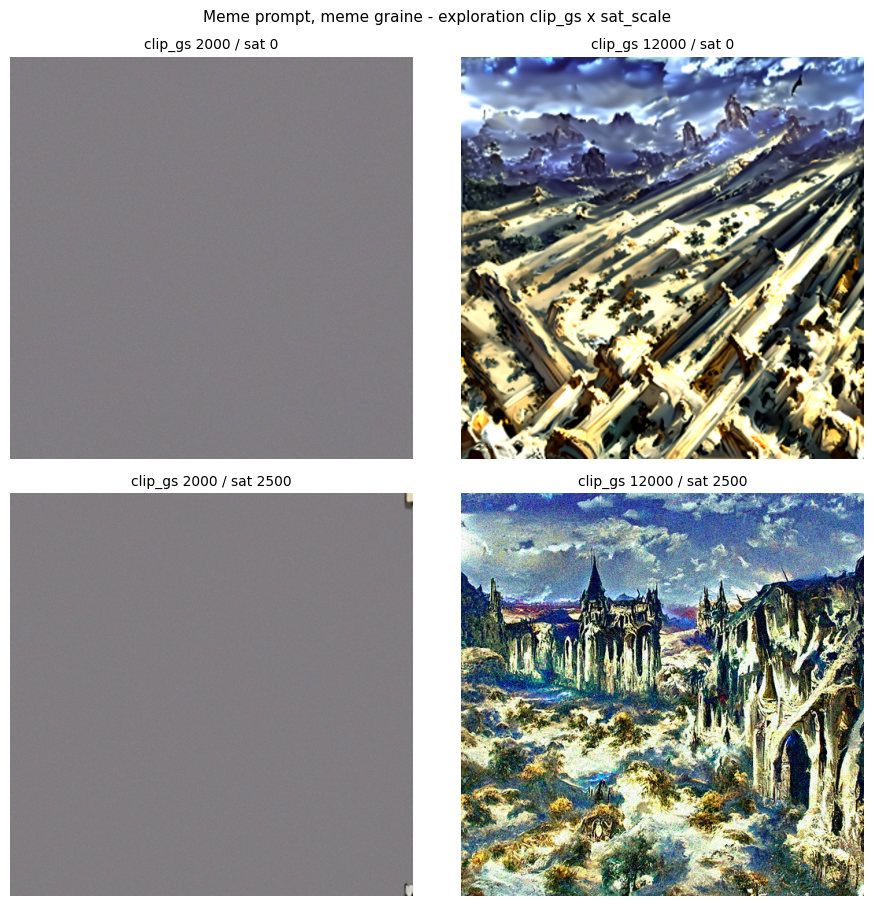

Provenance : 4 runs officiels du 18/09/2026 (moteur identique au hero), logs dans outputs_05_1/logs/grid_*.log


In [6]:
import numpy as np

GRID = [("clip_gs 2000 / sat 0", "grid_gs2000_sat0.png"),
        ("clip_gs 12000 / sat 0", "grid_gs12000_sat0.png"),
        ("clip_gs 2000 / sat 2500", "grid_gs2000_sat2500.png"),
        ("clip_gs 12000 / sat 2500", "grid_gs12000_sat2500.png")]

fig, axes = plt.subplots(2, 2, figsize=(9.2, 9.2))
for ax, (label, fname) in zip(axes.flat, GRID):
    ax.imshow(plt.imread(ASSETS / fname)); ax.axis("off"); ax.set_title(label, fontsize=10)
plt.suptitle("Meme prompt, meme graine - exploration clip_gs x sat_scale", fontsize=11)
plt.tight_layout(); plt.show()
print("Provenance : 4 runs officiels du 18/09/2026 (moteur identique au hero), "
      "logs dans outputs_05_1/logs/grid_*.log")

In [7]:
# Metriques : distance CLIP pleine-image (ViT-L/14) pour chaque cellule de la grille
def full_image_clip_dist(png_path, prompt):
    from PIL import Image as PILImage
    t = PILImage.open(png_path).convert("RGB").resize((512, 512))
    tin = clip_preprocess(t).unsqueeze(0).to("cuda")
    with torch.no_grad():
        e = clip_model.encode_image(tin.half()).float()
        tt = clip_model.encode_text(clip.tokenize([prompt]).to("cuda")).float()
    e, tt = F.normalize(e, dim=-1), F.normalize(tt, dim=-1)
    cos = (e * tt).sum(-1).item()
    sph = (e - tt).norm(dim=-1).div(2).arcsin().pow(2).mul(2).item()
    return cos, sph

rows = [("hero (gs 5000)", "hero_gothic.png")] + GRID
print(f"{'config':26s} {'cos CLIP':>9s} {'dist sph':>9s}")
for label, fname in rows:
    cos, sph = full_image_clip_dist(ASSETS / fname, PROMPT)
    print(f"{label:26s} {cos:>+9.3f} {sph:9.4f}")
print("\nAncres negatives pour calibrer la lecture : une image sans rapport au prompt")
print("donne typiquement cos ~ 0.02-0.15 (chameau CLIPasso : +0.071, robot : +0.023).")

config                      cos CLIP  dist sph
hero (gs 5000)                +0.318    0.7780
clip_gs 2000 / sat 0          +0.121    1.0499
clip_gs 12000 / sat 0         +0.326    0.7678
clip_gs 2000 / sat 2500       +0.125    1.0447
clip_gs 12000 / sat 2500      +0.342    0.7467

Ancres negatives pour calibrer la lecture : une image sans rapport au prompt
donne typiquement cos ~ 0.02-0.15 (chameau CLIPasso : +0.071, robot : +0.023).


Lecture mesurée (ViT-L/14, pleine image, graines identiques) : la similarité CLIP **croît
nettement avec `clip_gs`** — cos ≈ +0.12 à 2000, +0.32 à 5000 (hero), +0.33 à 12000 — et
`sat_scale` apporte un petit gain supplémentaire à forte guidance (+0.326 → +0.342). Sur cette
plage la guidance reste dans son régime utile ; les excès adverses connus de la guidance CLIP
(textures saturées, motifs répétitifs) se manifestent au-delà, et contenir précisément ces excès
était le rôle de `sat_scale` — l'arbitrage que les utilisateurs DD réglaient à la main pour
chaque prompt, et que l'entraînement conjoint (débruiteur appris *avec* l'alignement texte)
suppriméra chez Stable Diffusion.

## Pré-SD contre post-SD : ce que l'espace latent a changé

Même prompt, même graine, moteur d'époque contre moteur de la série : le UNet pixel 512 guidé
CLIP (à gauche) face à Z-Image via ComfyUI local (à droite). Deux mondes : 100 pas sur
786 432 pixels avec une loss externe contre 30 pas en espace latent avec un encodeur de texte
natif.

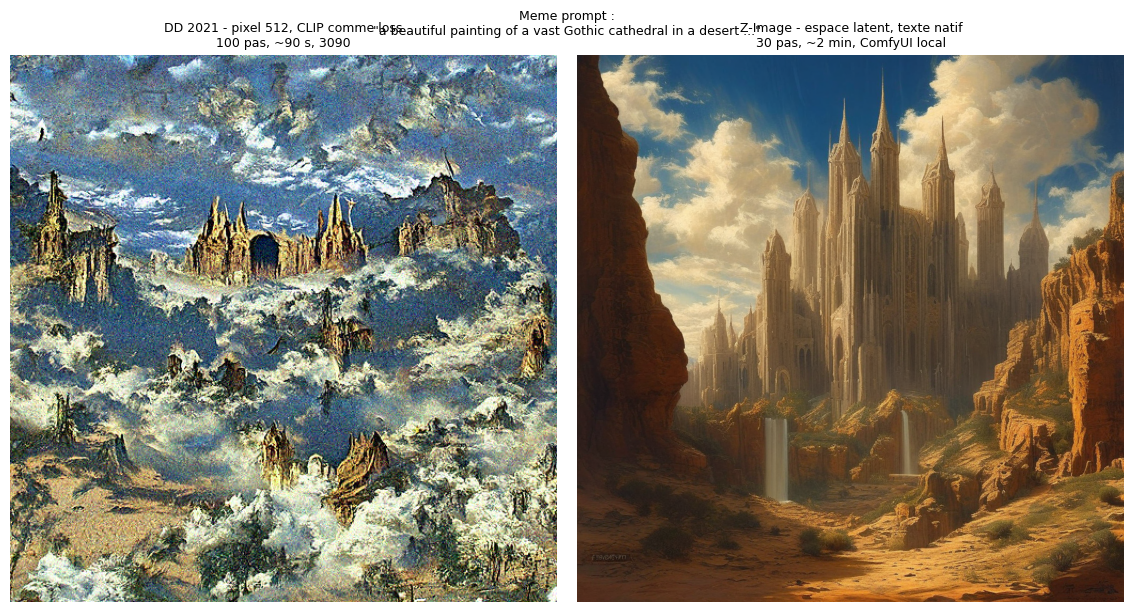

Provenance Z-Image : ComfyUI local (comfyui-qwen, endpoint qwen-image-edit.myia.io),
  workflow LuminaDiffusersNode, 30 pas, guidance 4.0, seed 0, 1024x1024, 18/09/2026.


In [8]:
modern = ASSETS / "modern_zimage.png"
fig, axes = plt.subplots(1, 2, figsize=(11.5, 6.2))
axes[0].imshow(plt.imread(hero)); axes[0].axis("off")
axes[0].set_title("DD 2021 - pixel 512, CLIP comme loss\n100 pas, ~90 s, 3090", fontsize=9)
axes[1].imshow(plt.imread(modern)); axes[1].axis("off")
axes[1].set_title("Z-Image - espace latent, texte natif\n30 pas, ~2 min, ComfyUI local", fontsize=9)
plt.suptitle(f"Meme prompt :\n\"{PROMPT[:60]}...\"", fontsize=9)
plt.tight_layout(); plt.show()
print("Provenance Z-Image : ComfyUI local (comfyui-qwen, endpoint qwen-image-edit.myia.io),")
print("  workflow LuminaDiffusersNode, 30 pas, guidance 4.0, seed 0, 1024x1024, 18/09/2026.")

In [9]:
for label, p in [("DiscoDiffusion (pixel 512)", hero), ("Z-Image (latent)", modern)]:
    cos, sph = full_image_clip_dist(p, PROMPT)
    print(f"{label:28s} cos CLIP = {cos:+.3f} | dist sph = {sph:.4f}")
print()
print("Couts mesures (3090 locale) : DD ~90 s/image (100 pas, fp32) ; Z-Image ~120 s/image")
print("(30 pas, cold start compris). Sur Colab 2021, un rendu DD durait 1-3 h.")

DiscoDiffusion (pixel 512)   cos CLIP = +0.318 | dist sph = 0.7780
Z-Image (latent)             cos CLIP = +0.318 | dist sph = 0.7776

Couts mesures (3090 locale) : DD ~90 s/image (100 pas, fp32) ; Z-Image ~120 s/image
(30 pas, cold start compris). Sur Colab 2021, un rendu DD durait 1-3 h.


Ce que la comparaison rend visible — et le résultat le plus instructif est le **égalité** :
sur la métrique CLIP elle-même, les deux moteurs arrivent au même alignement (+0.318). La
différence d'époque n'est donc pas la *reconnaissabilité globale* — une loss CLIP savait déjà
l'atteindre en 2021 — mais tout le reste : le modèle moderne **suit le prompt mot à mot**
(l'espace latent est entraîné avec l'alignement texte-image : fenêtres et arcs en nombre
cohérent, structure fine), à double résolution et sans réglage manuel, quand DD vise la
composition vaste avec textures d'estampe et demande son arbitrage guidance/saturation par
image. La cohérence structurelle fine était hors de portée d'une loss CLIP globale sur
cutouts ; le « look DD » est précisément cette contrainte transformée en esthétique.

## Exercices

In [10]:
# Exercice 1 - un autre style d'epoque
# Rejouer le hero avec un prompt DD different : par exemple
#   "a beautiful painting of a lighthouse in a stormy sea by ivan aivazovsky,
#    trending on artstation"
# puis comparer la composition obtenue (appeler generate_dd avec steps=100, clip_gs=5000).
# Indices : # Indice 1 - garder la grammaire "a beautiful painting of ... by ..., trending on
# artstation" ; # Etape 1 - generer ; # Etape 2 - afficher et mesurer la distance CLIP pleine
# image avec full_image_clip_dist.
result = None  # TODO etudiant
print("Exercice 1 a completer")

Exercice 1 a completer


In [11]:
# Exercice 2 - l'arbitrage guidance / horloge
# Rejouer le hero en variant skip_frac (0.1, 0.3) a clip_gs fixe : plus de pas a haut bruit
# (skip petit) laisse la composition se former ; skip grand fige une structure de bruit.
# # Indice : skip_frac controle t_start = int(999*(1-skip_frac)).
result = None  # TODO etudiant
print("Exercice 2 a completer")

Exercice 2 a completer


In [12]:
# Exercice 3 - quantifier le look
# Pour le hero et les 4 cellules de la grille, calculer l'energie de contour (Sobel) moyenne
# et la correlleer a clip_gs : la guidance forte fabrique-t-elle plus de texture ?
# # Indice : torch:numpy - convoluer l'image en niveaux de gris avec les noyaux de Sobel,
# prendre la moyenne de |G| ; # Etape 1 - fonction sobel_energy(png) ; # Etape 2 - tableau.
result = None  # TODO etudiant
print("Exercice 3 a completer")

Exercice 3 a completer


## Conclusion

DiscoDiffusion est mort en un jour — le 22 août 2022, quand Stable Diffusion a rendu gratuit,
rapide et local ce qui exigeait des heures de Colab. Mais tout ce qu'il avait **appris à la
communauté** a survécu : la guidance par cutouts et ses calendriers, l'équilibre
guidance/saturation, la grammaire des prompts longs, la culture du réglage fin par image. La
CLIP-guided diffusion en espace pixel n'était pas une impasse technique : c'était le laboratoire
où la génération guidée par texte a trouvé ses réflexes, dans le cadre dur d'un UNet qui ne
comprenait rien au texte. L'espace latent a ensuite divisé le coût par ~64 — assez pour changer
le monde, pas assez pour effacer le look.